In [3]:
# ================================================
#  SIH FINAL MODEL v5 — XGBoost 24/48/72 AQI
#  - Multi-horizon XGBoost (24h / 48h / 72h)
#  - Seasonal bias correction (winter vs other)
#  - AQI categories for citizens
#  - SHAP explainability for 24h model
#  - Model saving for backend
# ================================================

import numpy as np
import pandas as pd
import math
import joblib

from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt

b:\DataScienceBootCamp\Python\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# =========================
# 1. LOAD MASTER DATA
# =========================

# Change path if needed
DATA_PATH = "B:\SIH2\AI-Pollution-Forecast-and-Policy-Dashboard\ML\Training_Data\Final_Training_Dataset\MASTER_2023_2024.csv"

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["station", "date"]).reset_index(drop=True)

print("FULL DATA:", df.shape)
print(df[["date", "station"]].head())

<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
C:\Users\parth\AppData\Local\Temp\ipykernel_27076\2155662190.py:6: SyntaxWarning: invalid escape sequence '\S'
  DATA_PATH = "B:\SIH2\AI-Pollution-Forecast-and-Policy-Dashboard\ML\Training_Data\Final_Training_Dataset\MASTER_2023_2024.csv"
C:\Users\parth\AppData\Local\Temp\ipykernel_27076\2155662190.py:8: DtypeWarning: Columns (46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


FULL DATA: (27963, 60)
        date                station
0 2024-01-08  103_CRRI_Mathura_Road
1 2024-01-09  103_CRRI_Mathura_Road
2 2024-01-10  103_CRRI_Mathura_Road
3 2024-01-11  103_CRRI_Mathura_Road
4 2024-01-12  103_CRRI_Mathura_Road


In [5]:
# =====================================
# 2. STATION CODES & FEATURE COLUMNS
# =====================================

# Station → integer code
station_cats = df["station"].astype("category").cat.categories
station_to_code = {st: i for i, st in enumerate(station_cats)}
df["station_code"] = df["station"].map(station_to_code)

print("Total stations:", len(station_to_code))

TARGET = "aqi"

# feature columns: numeric only, excluding some
exclude_cols = ["aqi", "date", "station", "season", "year"]
feature_cols = [
    c for c in df.columns
    if c not in exclude_cols and df[c].dtype != "O"   # non-object (numeric) only
]

print("Num features:", len(feature_cols))
print("Example features:", feature_cols[:15])


Total stations: 78
Num features: 57
Example features: ['aqi_lag1', 'aqi_lag3', 'aqi_lag7', 'aqi_roll3d', 'aqi_roll7d', 'benzene (µg/m³)', 'blh_mean', 'co (mg/m³)', 'fire_3_day_sum', 'fire_7_day_sum', 'fire_count', 'fire_count_lag1', 'fire_count_lag3', 'fire_count_lag7', 'fire_count_roll7d']


In [6]:
# =====================================
# 3. CREATE 24/48/72 HORIZON TARGETS
# =====================================

df = df.sort_values(["station", "date"]).reset_index(drop=True)
grouped = df.groupby("station", group_keys=False)

# t+1, t+2, t+3 days ahead AQI
df["aqi_t+1"] = grouped[TARGET].shift(-1)   # 24h
df["aqi_t+2"] = grouped[TARGET].shift(-2)   # 48h
df["aqi_t+3"] = grouped[TARGET].shift(-3)   # 72h

# keep rows where we know all 3 future values
df_multi = df.dropna(subset=["aqi_t+1", "aqi_t+2", "aqi_t+3"]).reset_index(drop=True)

y_multi = df_multi[["aqi_t+1", "aqi_t+2", "aqi_t+3"]].values
X_multi = df_multi[feature_cols].values
dates_multi = df_multi["date"].values

print("MULTI-HORIZON DATA:", df_multi.shape)


MULTI-HORIZON DATA: (27729, 64)


In [7]:
# =====================================
# 4. TRAIN / VAL / TEST SPLIT
# =====================================

train_mask = df_multi["date"] <  pd.Timestamp("2024-10-01")
val_mask   = (df_multi["date"] >= pd.Timestamp("2024-10-01")) & (df_multi["date"] < pd.Timestamp("2024-11-01"))
test_mask  = df_multi["date"] >= pd.Timestamp("2024-11-01")

X_train, y_train = X_multi[train_mask], y_multi[train_mask]
X_val,   y_val   = X_multi[val_mask],   y_multi[val_mask]
X_test,  y_test  = X_multi[test_mask],  y_multi[test_mask]

dates_train = df_multi.loc[train_mask, "date"].values
dates_val   = df_multi.loc[val_mask,   "date"].values
dates_test  = df_multi.loc[test_mask,  "date"].values

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :",   y_val.shape)
print("X_test :", X_test.shape,  "y_test :",  y_test.shape)


X_train: (24258, 57) y_train: (24258, 3)
X_val  : (1209, 57) y_val  : (1209, 3)
X_test : (2262, 57) y_test : (2262, 3)


In [8]:
# =====================================
# 5. TRAIN MULTI-OUTPUT XGBOOST 24/48/72
# =====================================

base_xgb = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42
)

xgb_multi = MultiOutputRegressor(base_xgb)

# No eval_set here, MultiOutputRegressor doesn't support multi-column eval_set
xgb_multi.fit(X_train, y_train)

y_val_pred  = xgb_multi.predict(X_val)
y_test_pred = xgb_multi.predict(X_test)

def horizon_metrics(name, y_true, y_pred):
    for h, label in enumerate(["24h", "48h", "72h"]):
        mae  = mean_absolute_error(y_true[:, h], y_pred[:, h])
        rmse = math.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
        print(f"{name}  Horizon {label}:  MAE={mae:.2f},  RMSE={rmse:.2f}")
    print()

print("RAW XGBoost multi-output performance:")
horizon_metrics("VAL ", y_val,  y_val_pred)
horizon_metrics("TEST", y_test, y_test_pred)


RAW XGBoost multi-output performance:
VAL   Horizon 24h:  MAE=27.50,  RMSE=34.43
VAL   Horizon 48h:  MAE=40.54,  RMSE=50.27
VAL   Horizon 72h:  MAE=49.57,  RMSE=61.10

TEST  Horizon 24h:  MAE=35.96,  RMSE=45.77
TEST  Horizon 48h:  MAE=49.86,  RMSE=64.52
TEST  Horizon 72h:  MAE=60.03,  RMSE=76.31



In [9]:
y_val

array([[228.62650602, 232.15662651, 235.68674699],
       [232.15662651, 235.68674699, 239.21686747],
       [235.68674699, 239.21686747, 242.74698795],
       ...,
       [255.        , 299.        , 311.        ],
       [299.        , 311.        , 285.        ],
       [311.        , 285.        , 349.        ]], shape=(1209, 3))

In [10]:
y_val_pred

array([[206.1754 , 234.1099 , 224.76385],
       [212.3693 , 247.37872, 246.27628],
       [219.89975, 260.39545, 238.3035 ],
       ...,
       [251.83873, 239.57716, 240.19608],
       [262.14706, 283.10593, 258.67783],
       [266.30716, 262.97253, 246.75645]], shape=(1209, 3), dtype=float32)

In [11]:
y_test

array([[337., 374., 358.],
       [374., 358., 353.],
       [358., 353., 329.],
       ...,
       [327.,  85., 160.],
       [ 85., 160., 136.],
       [160., 136., 136.]], shape=(2262, 3))

In [13]:
y_test_pred

array([[360.5622 , 350.65674, 325.54196],
       [353.58472, 359.8173 , 356.81412],
       [380.6521 , 358.834  , 360.68942],
       ...,
       [327.8419 , 360.99292, 325.4231 ],
       [233.8645 , 258.96848, 235.62846],
       [166.3    , 211.27419, 218.19975]], shape=(2262, 3), dtype=float32)

In [14]:
# =====================================
# 6. SEASONAL BIAS CORRECTION
# =====================================

val_dates = pd.Series(pd.to_datetime(dates_val))
test_dates = pd.Series(pd.to_datetime(dates_test))

def learn_bias_by_season(y_true, y_pred, dates):
    months = dates.dt.month
    winter_mask = months.isin([11, 12, 1, 2])  # Nov, Dec, Jan, Feb
    
    bias = {}
    
    # winter bias
    if winter_mask.sum() > 0:
        bias["winter"] = (y_true[winter_mask] - y_pred[winter_mask]).mean(axis=0)
    else:
        bias["winter"] = np.zeros(3)
    
    # non-winter bias
    nonwinter_mask = ~winter_mask
    if nonwinter_mask.sum() > 0:
        bias["other"] = (y_true[nonwinter_mask] - y_pred[nonwinter_mask]).mean(axis=0)
    else:
        bias["other"] = np.zeros(3)
    
    return bias

bias_vecs = learn_bias_by_season(y_val, y_val_pred, val_dates)
print("Bias vectors (24h,48h,72h):", bias_vecs)


Bias vectors (24h,48h,72h): {'winter': array([0., 0., 0.]), 'other': array([ 1.61701373, 11.36513652, 18.49014032])}


In [15]:
def apply_bias(y_pred, dates, bias_dict):
    dates = pd.Series(pd.to_datetime(dates))
    months = dates.dt.month
    
    y_bc = y_pred.copy()
    winter_mask = months.isin([11, 12, 1, 2])
    nonwinter_mask = ~winter_mask
    
    y_bc[winter_mask]    = y_pred[winter_mask]    + bias_dict["winter"]
    y_bc[nonwinter_mask] = y_pred[nonwinter_mask] + bias_dict["other"]
    
    return y_bc

y_val_pred_bc  = apply_bias(y_val_pred,  val_dates,  bias_vecs)
y_test_pred_bc = apply_bias(y_test_pred, test_dates, bias_vecs)

print("After seasonal bias correction:")
horizon_metrics("VAL ", y_val,  y_val_pred_bc)
horizon_metrics("TEST", y_test, y_test_pred_bc)


After seasonal bias correction:
VAL   Horizon 24h:  MAE=27.57,  RMSE=34.39
VAL   Horizon 48h:  MAE=39.96,  RMSE=48.97
VAL   Horizon 72h:  MAE=48.49,  RMSE=58.23

TEST  Horizon 24h:  MAE=35.96,  RMSE=45.77
TEST  Horizon 48h:  MAE=49.86,  RMSE=64.52
TEST  Horizon 72h:  MAE=60.03,  RMSE=76.31



In [16]:
y_val

array([[228.62650602, 232.15662651, 235.68674699],
       [232.15662651, 235.68674699, 239.21686747],
       [235.68674699, 239.21686747, 242.74698795],
       ...,
       [255.        , 299.        , 311.        ],
       [299.        , 311.        , 285.        ],
       [311.        , 285.        , 349.        ]], shape=(1209, 3))

In [17]:
y_val_pred_bc

array([[207.79242, 245.47504, 243.254  ],
       [213.98631, 258.74387, 264.76642],
       [221.51677, 271.7606 , 256.79364],
       ...,
       [253.45575, 250.9423 , 258.68622],
       [263.76407, 294.47107, 277.16797],
       [267.92416, 274.33768, 265.24658]], shape=(1209, 3), dtype=float32)

In [18]:
y_test

array([[337., 374., 358.],
       [374., 358., 353.],
       [358., 353., 329.],
       ...,
       [327.,  85., 160.],
       [ 85., 160., 136.],
       [160., 136., 136.]], shape=(2262, 3))

In [19]:
y_test_pred_bc

array([[360.5622 , 350.65674, 325.54196],
       [353.58472, 359.8173 , 356.81412],
       [380.6521 , 358.834  , 360.68942],
       ...,
       [327.8419 , 360.99292, 325.4231 ],
       [233.8645 , 258.96848, 235.62846],
       [166.3    , 211.27419, 218.19975]], shape=(2262, 3), dtype=float32)

In [20]:
# =====================================
# 7. AQI CATEGORY ACCURACY (t+1 only)
# =====================================

def aqi_category_id(aqi):
    if aqi <= 50:  return 0  # Good
    if aqi <= 100: return 1  # Satisfactory
    if aqi <= 200: return 2  # Moderate
    if aqi <= 300: return 3  # Poor
    if aqi <= 400: return 4  # Very Poor
    return 5                # Severe

def category_report(name, y_true, y_pred):
    true_cat = np.array([aqi_category_id(v) for v in y_true[:, 0]])   # t+1
    pred_cat = np.array([aqi_category_id(v) for v in y_pred[:, 0]])   # t+1

    print(f"\n=== {name} AQI CATEGORY REPORT (t+1) ===")
    print(classification_report(true_cat, pred_cat, digits=3))
    print("Confusion matrix (rows=true, cols=pred):")
    print(confusion_matrix(true_cat, pred_cat))

# RAW
category_report("VAL RAW",  y_val,  y_val_pred)
category_report("TEST RAW", y_test, y_test_pred)

# BIAS-CORRECTED
category_report("VAL BIASED",  y_val,  y_val_pred_bc)
category_report("TEST BIASED", y_test, y_test_pred_bc)



=== VAL RAW AQI CATEGORY REPORT (t+1) ===
              precision    recall  f1-score   support

           1      0.714     0.185     0.294        27
           2      0.824     0.803     0.813       467
           3      0.586     0.704     0.640       382
           4      0.763     0.687     0.723       319
           5      1.000     0.071     0.133        14

    accuracy                          0.719      1209
   macro avg      0.778     0.490     0.521      1209
weighted avg      0.732     0.719     0.715      1209

Confusion matrix (rows=true, cols=pred):
[[  5  22   0   0   0]
 [  2 375  90   0   0]
 [  0  58 269  55   0]
 [  0   0 100 219   0]
 [  0   0   0  13   1]]

=== TEST RAW AQI CATEGORY REPORT (t+1) ===
              precision    recall  f1-score   support

           1      0.000     0.000     0.000         7
           2      0.797     0.328     0.465       323
           3      0.465     0.570     0.512       453
           4      0.649     0.769     0.704       

b:\DataScienceBootCamp\Python\venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
b:\DataScienceBootCamp\Python\venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
b:\DataScienceBootCamp\Python\venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]


XGB-24h model MAE: 27.49575355477046


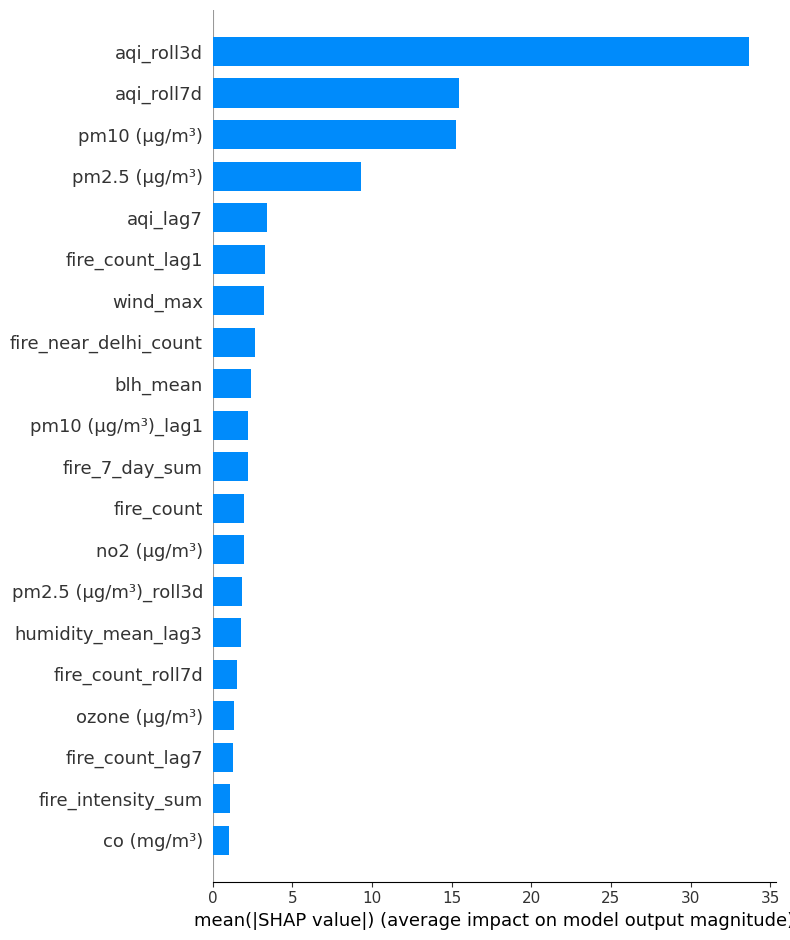

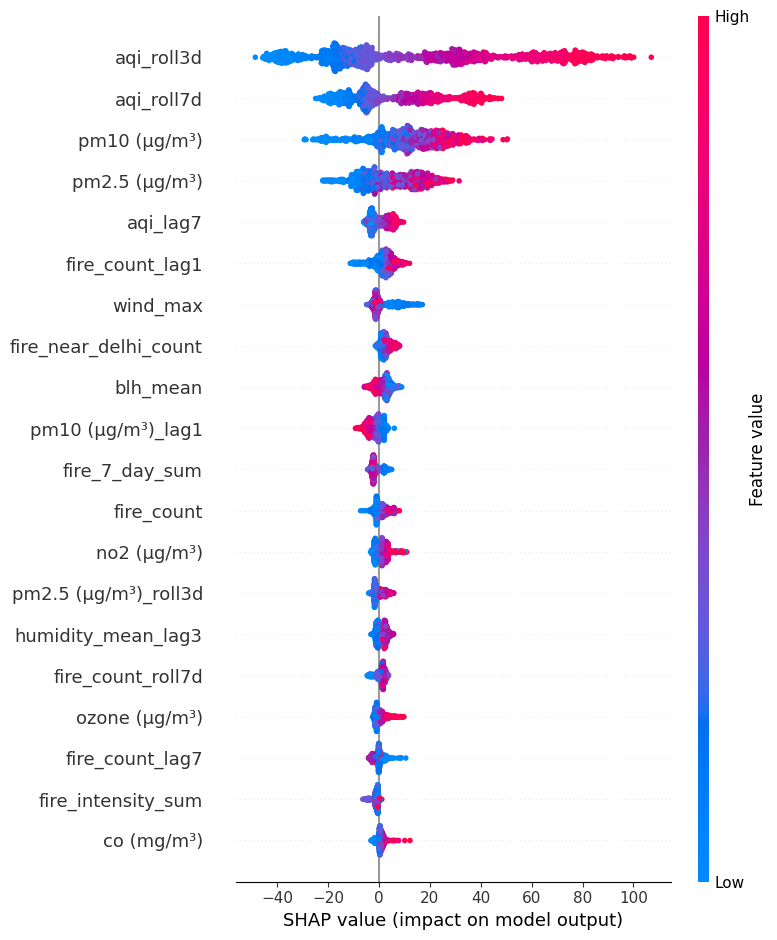

In [21]:
# =====================================
# 8. SHAP EXPLAINABILITY (24H MODEL)
# =====================================

# Single-target model for t+1 horizon
X_train_tab = X_train
y_train_24  = y_train[:, 0]
X_val_tab   = X_val
y_val_24    = y_val[:, 0]

xgb_24 = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42
)

xgb_24.fit(X_train_tab, y_train_24)

y_val_24_pred = xgb_24.predict(X_val_tab)
print("\nXGB-24h model MAE:", mean_absolute_error(y_val_24, y_val_24_pred))

# SHAP summary
explainer = shap.TreeExplainer(xgb_24)
sample_size = min(2000, X_val_tab.shape[0])
X_shap = X_val_tab[:sample_size]

shap_values = explainer.shap_values(X_shap)

plt.figure()
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, show=False)
plt.tight_layout()
plt.show()


In [32]:
# =====================================
# 9. 72-HOUR FORECAST FUNCTION (FOR API/UI)
# =====================================

def aqi_category(aqi):
    if aqi <= 50:  return "Good"
    if aqi <= 100: return "Satisfactory"
    if aqi <= 200: return "Moderate"
    if aqi <= 300: return "Poor"
    if aqi <= 400: return "Very Poor"
    return "Severe"

def forecast_72h(features_row: pd.Series, model=xgb_multi, bias_dict=bias_vecs):
    """
    features_row: one row from df_multi (must contain `date` + feature_cols)
    returns: dict with 24/48/72 hour AQI + category
    """
    x = features_row[feature_cols].values.reshape(1, -1)
    raw_pred = model.predict(x)[0]   # [aqi24, aqi48, aqi72]
    
    date = pd.to_datetime(features_row["date"])
    season = "winter" if date.month in [11,12,1,2] else "other"
    pred_bc = raw_pred + bias_dict[season]
    
    aqi24, aqi48, aqi72 = pred_bc.tolist()
    
    return {
        "aqi_24h":  float(aqi24),
        "aqi_48h":  float(aqi48),
        "aqi_72h":  float(aqi72),
        "cat_24h":  aqi_category(aqi24),
        "cat_48h":  aqi_category(aqi48),
        "cat_72h":  aqi_category(aqi72),
    }

# Example: last row
example_row = df.iloc[0]
forecast_72h(example_row)

{'aqi_24h': 329.6491394042969,
 'aqi_48h': 233.65884399414062,
 'aqi_72h': 327.60772705078125,
 'cat_24h': 'Very Poor',
 'cat_48h': 'Poor',
 'cat_72h': 'Very Poor'}

In [27]:
df['aqi']

0        325.0
1        347.0
2        219.0
3        327.0
4        347.0
         ...  
27958    426.0
27959    393.0
27960    432.0
27961    441.0
27962    441.0
Name: aqi, Length: 27963, dtype: float64

In [34]:
# =====================================
# 10. SAVE MODELS FOR BACKEND
# =====================================

# Save multi-output model (3 horizons)
joblib.dump(xgb_multi, r"B:\SIH2\AI-Pollution-Forecast-and-Policy-Dashboard\ML\Models\xgb_multi_24_48_72.pkl")

# Save 24h single model for SHAP reuse (optional)
joblib.dump(xgb_24, r"B:\SIH2\AI-Pollution-Forecast-and-Policy-Dashboard\ML\Models\xgb_24h_for_shap.pkl")

# Save bias vectors and meta
joblib.dump(bias_vecs, r"B:\SIH2\AI-Pollution-Forecast-and-Policy-Dashboard\ML\Models\seasonal_bias_vecs.pkl")
joblib.dump(feature_cols, r"B:\SIH2\AI-Pollution-Forecast-and-Policy-Dashboard\ML\Models\feature_cols.pkl")
joblib.dump(station_to_code, r"B:\SIH2\AI-Pollution-Forecast-and-Policy-Dashboard\ML\Models\station_to_code.pkl")  # if you want station-wise later

print("All models and artifacts saved.")

All models and artifacts saved.
